In [1]:
import json
import pandas as pd
import os

In [2]:
def extract_values(data, target_names):
    extracted_values = {}

    def traverse(obj):
        if isinstance(obj, dict):
            if 'name' in obj and obj['name'] in target_names and 'values' in obj:
                extracted_values[obj['name']] = obj['values']
            for key, value in obj.items():
                traverse(value)
        elif isinstance(obj, list):
            for item in obj:
                traverse(item)

    traverse(data)
    return extracted_values

# Function to extract only the 'values' from nested objects in specific columns
def clean_src_context_nested_values(dataframe):
    dataframe['src_context'] = dataframe['src_context'].apply(
        lambda x: x['values'] if isinstance(x, dict) and 'values' in x else x
    )
    return dataframe



# Function to extract only the 'values' field from lists of dictionaries
def extract_nested_values(column_data):
    values = column_data['values']
    print(values)
    new_values = []
    for val in values:
        new_values.extend(val['values'])
    return new_values

In [3]:
# Function to process a single JSON file
def process_json_file(file_path, target_names):
    with open(file_path, "r", encoding="utf-8") as file:
        json_data = json.load(file)

    # Extract values
    extracted_data = extract_values(json_data, target_names)

    # Convert the extracted data into a structured column-wise format
    max_length = max(len(v) for v in extracted_data.values()) if extracted_data else 0

    # Ensure all columns have the same number of rows by padding with None
    for key in extracted_data:
        while len(extracted_data[key]) < max_length:
            extracted_data[key].append(None)

    # Convert to DataFrame
    df_structured = pd.DataFrame(extracted_data)

    # Function to extract only the 'values' from nested objects in specific columns
    df_structured = clean_src_context_nested_values(df_structured)
    # Apply the function to the 'tgt_contexts' column
    if 'tgt_contexts' in df_structured.columns:
        df_structured['tgt_contexts'] = df_structured['tgt_contexts'].apply(extract_nested_values)
    if 'tgt_fact_aligned_sentences' in df_structured.columns:
        df_structured['tgt_fact_aligned_sentences'] = df_structured['tgt_fact_aligned_sentences'].apply(extract_nested_values)


    return df_structured



In [4]:
# Function to process all JSON files in a directory
def process_all_json_in_directory(directory_path, target_names, output_csv_path):
    all_dataframes = []
    
    for filename in os.listdir(directory_path):
        if filename.endswith(".json"):
            file_path = os.path.join(directory_path, filename)
            print(f"Processing: {file_path}")
            df = process_json_file(file_path, target_names)
            df["source_file"] = filename  # Add a column to track the source file
            all_dataframes.append(df)

    # Combine all DataFrames
    final_df = pd.concat(all_dataframes, ignore_index=True)

    # Save to CSV
    final_df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")

    print(f"Saved combined DataFrame to {output_csv_path}")

In [5]:
# Function to process all JSON files in a directory
def process_single_json_file(directory_path, filename, target_names, output_csv_path):
    all_dataframes = []

    file_path = os.path.join(directory_path, filename)
    print(f"Processing: {file_path}")
    df = process_json_file(file_path, target_names)
    df["source_file"] = filename  # Add a column to track the source file
    all_dataframes.append(df)

    # Combine all DataFrames
    final_df = pd.concat(all_dataframes, ignore_index=True)

    # Save to CSV
    final_df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")

    print(f"Saved combined DataFrame to {output_csv_path}")

    return final_df

## for WIKIGAP data

In [ ]:
# Target names to extract values from
# Directory containing JSON files
import urllib.parse
from datetime import datetime
import dill

# today = datetime.today().date()
today = '2025-03-16'
tgt_lang = "fr"
en_bio_id = "Oolong"
tgt_bio_id = "Thé Oolong"
decoded_tgt_bio_id = urllib.parse.unquote(tgt_bio_id)
file_name = f"annotation_{today}_{en_bio_id}_{tgt_lang}.json"

json_directory = "/Users/llupo/dev/infogap/scratch/annotation_save/wikimt_data"  # Change this to your directory path
output_csv = "wikigap_data_temp.csv"
#target_names = {'fact', 'src_context', 'person_name', 'tgt_contexts', 'gpt-4o_intersection_label', 'language', 'paragraph_index'}
target_names = {'fact', 'fact_aligned_sentence', 'src_context', 'person_name', 'tgt_contexts', 'tgt_fact_aligned_sentences','gpt-4o_intersection_label', 'language', 'paragraph_index'}


# # Process all JSON files in the directory and save the combined CSV
# process_all_json_in_directory(json_directory, target_names, output_csv)


df = process_single_json_file(json_directory, file_name, target_names, output_csv)

Processing: /Users/llupo/dev/infogap/scratch/ethics_annotation_save/wikigap_data/annotation_2025-03-16_Oolong_fr.json
[{'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': ['Baihao (白毫) est aussi appelé Oriental Beauty (東方美人).', 'AliShan (阿里山) est une chaîne de montagnes située à Taïwan.']}, {'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': ['AliShan est un lieu sacré pour les peuples indigènes Tsou.', 'Lishan (梨山) est cultivé à une altitude supérieure à 2 200 mètres.']}]
[{'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': ['Single Bush Dancong (单 枞) is also known as Phoenix oolong.', 'Dancong tea refers to a family of strip-style oolong teas from Guangdong Province.']}, {'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': ["Dong Ding is also known as 'Frozen Summit' or 'Ice Peak'.", 'Dong Ding is named after the mountain in Nantou County, Central Taiwan, where it is grown.']}]
[{'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': 

In [29]:
import loguru
logger = loguru.logger
BIO_SAVE_DIR = "/Users/llupo/dev/infogap/scratch/article_contents"
class BioFilenotFoundError(Exception):
    pass


def step_retrieve_prescraped_en_content_blocks(en_bio_id, 
                                              save_dir = BIO_SAVE_DIR,
                                               **kwargs):
    try:
        with open(f"{save_dir}/{en_bio_id}_en.pkl", 'rb') as f:
            return dill.load(f)
    except FileNotFoundError:
        raise BioFilenotFoundError(f"Could not find the prescraped bio file for {en_bio_id}")


def step_retrieve_prescraped_tgt_content_blocks(tgt_bio_id, tgt_lang: str, **kwargs):
    try: 
        logger.info(f"Retrieving {tgt_bio_id}_{tgt_lang} from {BIO_SAVE_DIR}")
        with open(f"{BIO_SAVE_DIR}/{tgt_bio_id}_{tgt_lang}.pkl", 'rb') as f:
            return dill.load(f)
    except FileNotFoundError:
        raise BioFilenotFoundError(f"Could not find the prescraped bio file for {tgt_bio_id}")


en_blocks = step_retrieve_prescraped_en_content_blocks(en_bio_id, save_dir = BIO_SAVE_DIR)
tgt_blocks = step_retrieve_prescraped_tgt_content_blocks(tgt_bio_id, tgt_lang, save_dir = BIO_SAVE_DIR)
   

2025-03-17 08:51:30.953 | INFO     | __main__:step_retrieve_prescraped_tgt_content_blocks:20 - Retrieving Thé Oolong_fr from /Users/llupo/dev/infogap/scratch/article_contents


In [30]:
def process_paragraphs_with_headers(data):
    processed_data = []
    current_headers = {}  # Stores active headers at different levels
    paragraph_index = 0  # Tracks paragraph numbering

    for item in data:
        # Detect headers dynamically
        header_match = next((k for k in item.keys() if k.startswith("header")), None)
        if header_match:
            # Extract header level from key (e.g., header_1 → level 1, header_2 → level 2)
            level = int(header_match.split("_")[1]) if "_" in header_match else 1
            header_text = item[header_match]

            # Update the current active headers
            current_headers[level] = header_text
            # Remove deeper headers if a higher-level header appears
            current_headers = {k: v for k, v in current_headers.items() if k <= level}

            continue  # Skip processing since it's a header

        # Process paragraphs
        elif "paragraph" in item:
            paragraph_entry = {
                "index": paragraph_index,
                "paragraph": item["paragraph"]
            }

            # Assign the most relevant parent headers
            for lvl in sorted(current_headers.keys()):
                paragraph_entry[f"header_{lvl}"] = current_headers[lvl]

            processed_data.append(paragraph_entry)
            paragraph_index += 1  # Increment paragraph index

    return processed_data


processed_en_blocks = process_paragraphs_with_headers(en_blocks)
processed_tgt_blocks = process_paragraphs_with_headers(tgt_blocks)
# Print output for verification
import json
print(json.dumps(processed_en_blocks,indent=4, ensure_ascii=False))
print(json.dumps(processed_tgt_blocks,indent=4, ensure_ascii=False))

[
    {
        "index": 0,
        "paragraph": "Oolong (UK: , US: ; simplified Chinese: 乌龙茶; traditional Chinese: 烏龍茶; pinyin: wūlóngchá; Pe̍h-ōe-jī: o͘-liông tê, \"black dragon\" tea) is a traditional semi-oxidized Chinese tea (Camellia sinensis) produced through a process that includes withering the leaves under strong sun and allowing some oxidation to occur before curling and twisting. Most oolong teas, especially those of fine quality, involve unique tea plant cultivars that are exclusively used for particular varieties. The degree of oxidation, which is controlled by the length of time between picking and final drying, can range from 8% to 85% depending on the variety and production style. Oolong is especially popular in southeastern China and among ethnic Chinese in Southeast Asia, as is the Fujian preparation process known as the gongfu tea ceremony."
    },
    {
        "index": 1,
        "paragraph": "Different styles of oolong tea can vary widely in flavor. They can be s

In [31]:
# Sample function to process text (modify as needed)
# Retrieve paragraph by index
def get_header_by_paragraph_index(index, data, lvl):
    for p in data:
        if p["index"] == index:
            if lvl in p:
                return p[lvl]
    return None

df_en = df[df["language"] == "en"]
df_tgt = df[df["language"] != "en"]


# Apply function to 'text' column and store result in 'processed_text' column
df_en["header_1"] = df_en["paragraph_index"].apply(get_header_by_paragraph_index, args=(processed_en_blocks, "header_1"))
df_tgt["header_1"] = df_tgt["paragraph_index"].apply(get_header_by_paragraph_index, args=(processed_tgt_blocks, "header_1"))

df_en["header_2"] = df_en["paragraph_index"].apply(get_header_by_paragraph_index, args=(processed_en_blocks, "header_2"))
df_tgt["header_2"] = df_tgt["paragraph_index"].apply(get_header_by_paragraph_index, args=(processed_tgt_blocks,"header_2"))


df_en = df_en.where(pd.notna(df_en), None)  # Replaces NaN with None
df_tgt = df_tgt.where(pd.notna(df_tgt), None)

/var/folders/ks/t4xykdjd3qj06ylqcn6zkprm0000gn/T/ipykernel_44905/2780331673.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_en["header_1"] = df_en["paragraph_index"].apply(get_header_by_paragraph_index, args=(processed_en_blocks, "header_1"))
/var/folders/ks/t4xykdjd3qj06ylqcn6zkprm0000gn/T/ipykernel_44905/2780331673.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tgt["header_1"] = df_tgt["paragraph_index"].apply(get_header_by_paragraph_index, args=(processed_tgt_blocks, "header_1"))
/var/fo

In [32]:
from deep_translator import GoogleTranslator
import pandas as pd

# Define a helper function to translate non-null values

def translate_headers(df, src_lang, tgt_lang):
    """
    Translates `header_1` and `header_2` in the given DataFrame into a target language.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame with `header_1` and `header_2`.
        src_lang (str): The source language code (default: 'zh' for Chinese).
        tgt_lang (str): The target language code (default: 'en' for English).
        
    Returns:
        pd.DataFrame: DataFrame with two new columns: `header_1_translated` and `header_2_translated`.
    """
    translator = GoogleTranslator(source=src_lang, target=tgt_lang)
    def translate_text(text):
        return translator.translate(text) if pd.notna(text) and text not in ["None", None] else text


    df["header_1_translated"] = df["header_1"].apply(translate_text)
    df["header_2_translated"] = df["header_2"].apply(translate_text)

    return df
LANG_CODE_MAPPING = {
    "en": "en",  # English
    "fr": "fr",  # French
    "ru": "ru",  # Russian
    "zh": "zh-TW"   # Chinese (Simplified)
}
df_en_translated = translate_headers(df_en, LANG_CODE_MAPPING["en"], LANG_CODE_MAPPING[tgt_lang])
df_tgt_translated = translate_headers(df_tgt, LANG_CODE_MAPPING[tgt_lang], LANG_CODE_MAPPING["en"])

In [33]:
df_tgt_translated

,fact,person_name,fact_aligned_sentence,src_context,tgt_contexts,tgt_fact_aligned_sentences,paragraph_index,gpt-4o_intersection_label,language,source_file,header_1,header_2,header_1_translated,header_2_translated
1,Fenghuang Dancong est originaire de la région ...,Oolong,Fenghuang Dancong (风凰单枞).,"[Fenghuang Dancong est un type de thé., Fenghu...",[Single Bush Dancong (单 枞) is also known as Ph...,"[Single Bush Dancong (单 枞) (""Phoenix oolong""),...",26,yes,fr,annotation_2025-03-16_Oolong_fr.json,types de thés oolong,chine,Types of Oolong teas,China
2,"La feuille peut être froissée, torsadée, ou ro...",Oolong,Celui-ci est réalisé de diverses manières suiv...,[Le roulage a pour but de déplacer les huiles ...,[The manufacturing of oolong tea involves repe...,[The manufacturing of oolong tea involves repe...,10,yes,fr,annotation_2025-03-16_Oolong_fr.json,fabrication,None,manufacturing,None
4,Exemple : Baozhong (包种) de Taïwan,Oolong,Exemple : Baozhong (包种) de Taïwan.,[Fabriqués à partir de la méthode dite chinois...,[Recommended brewing techniques for oolong tea...,[Recommended brewing techniques for oolong tea...,20,yes,fr,annotation_2025-03-16_Oolong_fr.json,types de thés oolong,faiblement oxydés,Types of Oolong teas,weakly oxidized
5,"Dans certains Oolong, tels que le Yan Cha, cet...",Oolong,"Dans certains Oolong, tels que le Yan Cha, cet...","[Cette dessication se fait, pour les Oolong ar...",[The gongfu method involves multiple short ste...,[Such vessels are used in the gongfu method of...,12,yes,fr,annotation_2025-03-16_Oolong_fr.json,fabrication,None,manufacturing,None
6,Ce thé aurait été dès le début fabriqué par se...,Oolong,"Dans une autre version de la même-époque, prov...","[Ce thé a évolué vers la semi-oxydation., Dans...","[Oolong (UK: , US: ; simplified Chinese: 乌龙茶; ...","[Oolong (UK: , US: ; simplified Chinese: 乌龙茶; ...",3,yes,fr,annotation_2025-03-16_Oolong_fr.json,histoire,origines,history,origins
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,Ce thé est apprécié pour son arôme floral et s...,Oolong,Si Ji Chun (四季春),[Ce thé est également connu sous le nom de 'Qu...,[Different styles of oolong tea can vary widel...,[Different styles of oolong tea can vary widel...,39,yes,fr,annotation_2025-03-16_Oolong_fr.json,types de thés oolong,taïwan,Types of Oolong teas,Taiwan
375,Il est souvent récolté plusieurs fois par an.,Oolong,Si Ji Chun (四季春),"[Il est originaire de Taïwan., Ce thé est appr...","[For a single infusion, 1- to 5-minute steepin...","[For a single infusion, 1- to 5-minute steepin...",39,yes,fr,annotation_2025-03-16_Oolong_fr.json,types de thés oolong,taïwan,Types of Oolong teas,Taiwan
376,Le passage du thé noir au Oolong permet de mon...,Oolong,"Dans plusieurs régions productrices, telles qu...","[Parmi les autres régions productrices, on peu...","[Oolong teas are not as strong as black teas.,...",[Oolong teas share some characteristics with b...,18,no,fr,annotation_2025-03-16_Oolong_fr.json,régions productrices,None,Producing regions,None
378,AliShan est un lieu sacré pour les peuples ind...,Oolong,AliShan (阿里山),"[AliShan abrite des forêts de cyprès géants., ...",[Lishan oolong is grown at an elevation above ...,"[It is grown at an elevation above 1,600 m (5,...",33,yes,fr,annotation_2025-03-16_Oolong_fr.json,types de thés oolong,taïwan,Types of Oolong teas,Taiwan


In [ ]:
import openai
import pandas as pd
# Initialize OpenAI client

client = openai.AzureOpenAI(
    api_key=os.getenv("THE_KEY"),
    api_version="2023-05-15",       
    azure_endpoint=os.getenv("URL_ENDPOINT")
)

def translate_facts(df, src_lang, tgt_lang):
    """
    Translates `header_1` and `header_2` using OpenAI GPT-4o.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with `header_1` and `header_2`.
        src_lang (str): Source language (e.g., 'Chinese').
        tgt_lang (str): Target language (e.g., 'English').
        
    Returns:
        pd.DataFrame: Updated DataFrame with translated headers.
    """
    print("Translating facts...from {} to {}".format(src_lang, tgt_lang))
    def translate_text(text):
        if pd.notna(text) and text not in ["None", None]:
            try:
                response = client.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[
                        {"role": "user", "content": f"Translate the following content: {text} to {tgt_lang}, return the translation only. Do not provide any additional text outside the translation."}
                    ]
                )
                print(text)
                print(response.choices[0].message.content.strip())
                return response.choices[0].message.content.strip()

            except Exception as e:
                return f"Translation Error: {e}"
        return text

    # df["header_1_translated"] = df["header_1"].apply(translate_text)
    # df["header_2_translated"] = df["header_2"].apply(translate_text)
    df["fact_translated"] = df["fact"].apply(translate_text)

    return df

In [35]:

LANG_CODE_MAPPING = {
    "en": "English",  # English
    "fr": "French",  # French
    "ru": "Russian",  # Russian
    "zh": "Chinese"   # Chinese (Simplified)
}

df_en_translated = translate_facts(df_en, LANG_CODE_MAPPING["en"], LANG_CODE_MAPPING[tgt_lang])
df_tgt_translated = translate_facts(df_tgt, LANG_CODE_MAPPING[tgt_lang], LANG_CODE_MAPPING["en"])

df = pd.concat([df_en_translated, df_tgt_translated])

Translating facts...from English to French
Lishan (梨山) oolong is grown near Lishan mountain in the north-central region of Taiwan.
Le oolong Lishan (梨山) est cultivé près de la montagne Lishan dans la région nord-centre de Taïwan.
Teaghrelins were recently isolated from other oolong tea varieties.
Les teaghrelins ont récemment été isolés d'autres variétés de thé oolong.
Huangjin Gui has a very fragrant flavor.
Huangjin Gui a une très agréable saveur.
Due to high domestic demand, most Taiwanese tea is bought and consumed in Taiwan.
En raison de la forte demande intérieure, la plupart du thé taïwanais est acheté et consommé à Taïwan.
Different styles of oolong tea can vary widely in flavor.
Différents styles de thé oolong peuvent varier largement en saveur.
New age specialty tea companies have started offering infused oolong teas.
De nouvelles entreprises de thé de spécialité ont commencé à proposer des thés oolong infusés.
The expansion of the tea industry in Taiwan has been in line with

In [36]:
df = df.where(pd.notna(df), None)
df = df[df['gpt-4o_intersection_label'] == 'no']
df

,fact,person_name,fact_aligned_sentence,src_context,tgt_contexts,tgt_fact_aligned_sentences,paragraph_index,gpt-4o_intersection_label,language,source_file,header_1,header_2,header_1_translated,header_2_translated,fact_translated
0,Lishan (梨山) oolong is grown near Lishan mounta...,Oolong,Lishan (梨山) oolong: Grown near Lishan mountain...,"[Alishan oolong produces golden yellow tea., T...",[Baihao (白毫) est aussi appelé Oriental Beauty ...,[Baihao (白毫) aussi appelé Oriental Beauty (東方美...,23,no,en,annotation_2025-03-16_Oolong_fr.json,varieties,taiwan,variétés,Taïwan,Le oolong Lishan (梨山) est cultivé près de la m...
3,Teaghrelins were recently isolated from other ...,Oolong,Teaghrelins were isolated from Chin-shin oolon...,[Teaghrelins were isolated from Chin-shin oolo...,"[Le bouche-à-oreille déforma le nom du thé, de...","[Lorsqu'il goûta l'infusion, son goût l'enchan...",38,no,en,annotation_2025-03-16_Oolong_fr.json,characteristics,teaghrelins,caractéristiques,teaghrelins,Les teaghrelins ont récemment été isolés d'aut...
8,Huangjin Gui has a very fragrant flavor.,Oolong,"Huangjin Gui (""Golden Cassia"" or ""Golden Osman...",[Huangjin Gui is also known as 'Golden Cassia'...,[Fenghuang Dancong est réputé pour ses arômes ...,"[Fenghuang Dancong (风凰单枞)., Fenghuang Dancong ...",14,no,en,annotation_2025-03-16_Oolong_fr.json,varieties,fujian,variétés,Fujian,Huangjin Gui a une très agréable saveur.
10,Different styles of oolong tea can vary widely...,Oolong,Different styles of oolong tea can vary widely...,[Oolong is especially popular in southeastern ...,"[Le bouche-à-oreille déforma le nom du thé, de...","[Lorsqu'il goûta l'infusion, son goût l'enchan...",1,no,en,annotation_2025-03-16_Oolong_fr.json,None,None,None,None,Différents styles de thé oolong peuvent varier...
16,The expansion of the tea industry in Taiwan ha...,Oolong,"Since the 1970s, the tea industry in Taiwan ha...",[Many of the teas which are grown in Fujian pr...,[La constitution de classes moyennes et aisées...,"[Depuis, elle se développe dans l'ensemble des...",18,no,en,annotation_2025-03-16_Oolong_fr.json,varieties,taiwan,variétés,Taïwan,L'expansion de l'industrie du thé à Taïwan a é...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,AliShan (阿里山) est une chaîne de montagnes situ...,Oolong,AliShan (阿里山),[Dongding (凍頂) est cultivé notamment à Lugu (鹿...,"[The tea has a unique fruity aroma., Lishan (梨...",[It produces golden yellow tea with a unique f...,33,no,fr,annotation_2025-03-16_Oolong_fr.json,types de thés oolong,taïwan,Types of Oolong teas,Taiwan,AliShan (阿里山) is a mountain range located in T...
353,Le but est de ne plus faire dépendre la produc...,Oolong,"À Taïwan, la consommation locale est très fort...",[La constitution de classes moyennes et aisées...,"[Oolong teas are not as strong as black teas.,...",[Oolong teas share some characteristics with b...,45,no,fr,annotation_2025-03-16_Oolong_fr.json,consommation,None,consumption,None,The goal is to no longer make oolong productio...
358,Il est souvent utilisé pour produire du thé Oo...,Oolong,Jin Xuan (金萱),[Il a été créé par le Tea Research and Extensi...,"[In Taiwan, oolong teas are also known as qing...","[In Taiwan, oolong teas are also known as qing...",38,no,fr,annotation_2025-03-16_Oolong_fr.json,types de thés oolong,taïwan,Types of Oolong teas,Taiwan,It is often used to produce Oolong tea.
365,Le passage du thé noir au Oolong assure une pl...,Oolong,"Dans plusieurs régions productrices, telles qu...","[Dans plusieurs régions productrices, telles q...","[Withering, rolling, shaping, and firing are s...","[Withering, rolling, shaping, and firing are s...",18,no,fr,annotation_2025-03-16_Oolong_fr.json,régions productrices,None,Producing regions,None,The transition from black tea to Oolong ensure...


In [ ]:
df.to_csv(f"/Users/llupo/dev/infogap/scratch/annotation_save/wikimt_data/csv/{en_bio_id}_{tgt_lang}.csv", index=False)

In [ ]:
import json


# Load JSON file correctly
def load_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        try:
            return json.load(f)  # Ensure JSON is properly loaded as a dictionary
        except json.JSONDecodeError as e:
            print(f"Error loading JSON: {e}")
            return {}

# Get available languages for a person
def get_languages(data, person_name):
    return list(data.get(person_name, {}).get('languages', {}).keys())

# Get header_1 values for a given person and language
def get_headers(data, person_name, language):
    return list(data.get(person_name, {}).get('languages', {}).get(language, {}).get('headers', {}).keys())

# Get entries under a specific header_1
def get_entries(data, person_name, language, header_1):
    return data.get(person_name, {}).get('languages', {}).get(language, {}).get('headers', {}).get(header_1, {}).get('entries', [])

# Main testing function
def test_json(json_file):
    data = load_json(json_file)

    # Test: Get languages for "Person A"
    person_name = "Wonton"
    print(f"Data type after loading: {type(data)}")  # Should be <class 'dict'>
    languages = get_languages(data, person_name)
    print(f"Languages available for {person_name}: {languages}")

    if languages:
        # Test: Get header_1 values for "Person A" in "English"
        language = languages[0]  # Pick first available language
        headers = get_headers(data, person_name, language)
        print(f"Headers in {language} for {person_name}: {headers}")

        if headers:
            # Test: Get entries under first header_1
            selected_header = headers[0]
            entries = get_entries(data, person_name, language, selected_header)
            print(f"Entries under '{selected_header}' in {language}:")
            for entry in entries:
                print(json.dumps(entry, indent=4, ensure_ascii=False))

# Run test

test_json("/Users/llupo/dev/infogap/scratch/annotation_save/wikimt_data/json/Wonton.json")

Data type after loading: <class 'dict'>
Languages available for Wonton: []


# For Wikiworkshop analysis 


Processing file: /Users/llupo/dev/infogap/scratch/ethics_annotation_save/wikigap_data/annotation_2025-03-07_Xiaolongbao_zh.json
[{'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': ['汤包源于北宋京城开封的灌汤包。', '灌汤包的特色是馅料经过蒸煮化为汁水。']}, {'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': ['小笼包在天津得到了传扬。', '小笼馒头的历史可上溯自北宋。']}]
[{'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': ['Xiaolongbao originated in Changzhou, Jiangsu province.', 'Xiaolongbao was created by Wan Hua Tea House during the years of Daoguang Emperor (1820 to 1850).']}, {'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': ['The restaurant Goubuli was founded in 1858 by a young man named Gouzi.', 'Gouzi named his xiaolongbao after himself as Goubuli later.']}]
[{'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': ['常州加蟹小笼包才能达到最好的口感。', '吃小笼包时应该把小笼包挟出香醋碟子里浸一下。']}, {'name': '', 'datatype': 'Utf8', 'bit_settings': '', 'values': ['同治十年(1871年)，黄老板病故，黄明贤继承日华轩。', '彼时古猗园常为文人墨客聚会之所。']}]
[{'n

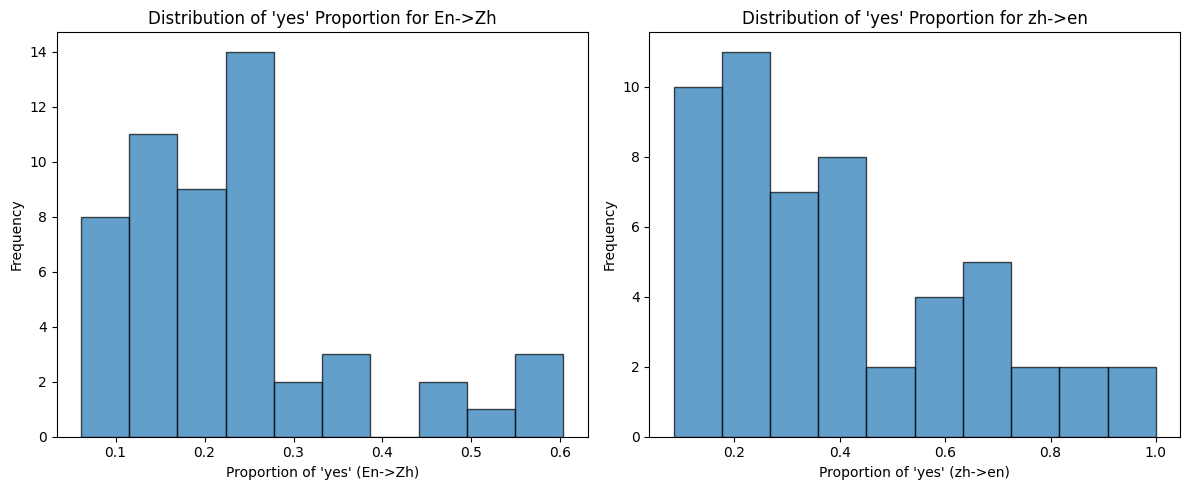

ModuleNotFoundError: No module named 'ace_tools'

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# Function to iterate through all JSON files ending with "_zh"
def process_all_json_files(directory, target_names):
    results = []

    for filename in os.listdir(directory):
        if filename.endswith("_zh.json"):  # Ensure the file ends with "_zh.json"
            file_path = os.path.join(directory, filename)
            print(f"Processing file: {file_path}")  # Debugging log

            try:
                df = process_json_file(file_path, target_names)
                df['source_file'] = filename  # Add a column to track the source file
                
                # Perform analysis on the processed dataset
                en_proportion, zh_proportion = analyze_dataset(df)

                # Store the result
                results.append({"dataset": filename, "en->zh": en_proportion, "zh->en": zh_proportion})

            except Exception as e:
                print(f"Error processing {filename}: {e}")

    # Convert results to DataFrame
    result_df = pd.DataFrame(results)
    
    if not result_df.empty:
        visualize_results(result_df)
    
    return result_df

# Function to analyze dataset
def analyze_dataset(df):
    # Ensure 'language' and 'gpt-4o_intersection_label' columns exist
    if 'language' not in df.columns or 'gpt-4o_intersection_label' not in df.columns:
        print("Required columns not found in dataset.")
        return None, None

    # Filter by language
    en_df = df[df["language"] == "en"]
    zh_df = df[df["language"] == "zh"]

    # Calculate proportion of 'yes' in 'gpt-4o_intersection_label'
    en_yes_proportion = en_df["gpt-4o_intersection_label"].eq("yes").mean() if not en_df.empty else 0
    zh_yes_proportion = zh_df["gpt-4o_intersection_label"].eq("yes").mean() if not zh_df.empty else 0

    return en_yes_proportion, zh_yes_proportion

# Function to visualize results
def visualize_results(result_df):
    plt.figure(figsize=(12, 5))

    # Histogram for en->zh proportions
    plt.subplot(1, 2, 1)
    plt.hist(result_df["en->zh"].dropna(), bins=10, edgecolor="black", alpha=0.7)
    plt.xlabel("Proportion of 'yes' (En->Zh)")
    plt.ylabel("Frequency")
    plt.title("Distribution of 'yes' Proportion for En->Zh")

    # Histogram for zh->en proportions
    plt.subplot(1, 2, 2)
    plt.hist(result_df["zh->en"].dropna(), bins=10, edgecolor="black", alpha=0.7)
    plt.xlabel("Proportion of 'yes' (zh->en)")
    plt.ylabel("Frequency")
    plt.title("Distribution of 'yes' Proportion for zh->en")

    plt.tight_layout()
    plt.show()

# Example usage
directory_path = "/Users/llupo/dev/infogap/scratch/annotation_save/wikimt_data"  # Update this with the correct directory
target_names =  {'fact', 'src_context', 'person_name', 'tgt_contexts', 'gpt-4o_intersection_label', 'language', 'paragraph_index'}

processed_data_summary = process_all_json_files(directory_path, target_names)

# Display final results
if processed_data_summary is not None:
A    tools.display_dataframe_to_user(name="Processed Data Summary", dataframe=processed_data_summary)

In [11]:
if processed_data_summary is not None:
    print(f"Number of datasets processed: {len(processed_data_summary)}")

Number of datasets processed: 53


## for BENCHMARK project

In [ ]:
# # Target names to extract values from
# # Directory containing JSON files
# json_directory = "/Users/llupo/dev/infogap/scratch/annotation_save"  # Change this to your directory path
# output_csv = "combined_data.csv"
# target_names = {'fact', 'src_context', 'person_name', 'tgt_contexts', 'gpt-4o_intersection_label', 'sam_annotations', 'language', 'fact_index'}

# # # Process all JSON files in the directory and save the combined CSV
# # process_all_json_in_directory(json_directory, target_names, output_csv)

# file_name = "annotation_2025-02-28_Hummus.json"
# process_single_json_file(json_directory, file_name, target_names, output_csv)

In [18]:
full = './wiki_text_process_test/english.csv'

full_df = pd.read_csv(full)

fact_index = [61, 82, 135, 117, 4, 143, 82, 69, 23, 99, 24, 24, 78, 111, 24]
intersection = []
for index in fact_index:
    intersection.extend(full_df[full_df['fact_index'] == index]['gpt-4o_intersection_label'])
    
intersection



['no',
 'no',
 'no',
 'no',
 'yes',
 'no',
 'no',
 'no',
 'no',
 'no',
 'no',
 'no',
 'no',
 'no',
 'no']